# Phase 0 — Dataset Understanding & Preprocessing
### Emergency Response Analytics and Decision Optimization
**Course:** Data Analytics (10204210) | **Student:** [Your Name / ID]

---
This notebook covers:
1. Loading the dataset
2. Basic structure inspection
3. Missing value analysis
4. Unique value inspection (categorical columns)
5. Descriptive statistics (numeric columns)
6. Timestamp parsing
7. Duplicate check
8. Encoding categorical columns for future use
9. Saving the cleaned dataset

---
## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option('display.max_columns', None) # show ALL columns, never truncate
pd.set_option('display.float_format', '{:.4f}'.format) # show floats to 4 decimals

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load Dataset

In [3]:

FILE_PATH = 'emergency_service.csv'

df = pd.read_csv(FILE_PATH)

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns')

Dataset loaded successfully.
Shape: 155,779 rows  x  18 columns


---
## 3. Basic Structure Inspection

In [4]:
print('=== COLUMN NAMES ===')
print(df.columns.tolist())
print()
print('=== DATA TYPES ===')
print(df.dtypes)

=== COLUMN NAMES ===
['Timestamp', 'Incident_Severity', 'Incident_Type', 'Region_Type', 'Traffic_Congestion', 'Weather_Condition', 'Ambulance_Availability', 'Hospital_Capacity', 'Distance_to_Incident', 'Number_of_Injuries', 'Specialist_Availability', 'Road_Type', 'Emergency_Level', 'Ambulance_Speed', 'Fuel_Level', 'Weather_Impact', 'Dispatch_Coordinator', 'Response_Time']

=== DATA TYPES ===
Timestamp                   object
Incident_Severity           object
Incident_Type               object
Region_Type                 object
Traffic_Congestion          object
Weather_Condition           object
Ambulance_Availability      object
Hospital_Capacity            int64
Distance_to_Incident       float64
Number_of_Injuries           int64
Specialist_Availability     object
Road_Type                   object
Emergency_Level             object
Ambulance_Speed            float64
Fuel_Level                 float64
Weather_Impact              object
Dispatch_Coordinator        object
Response_T

In [5]:
print('=== FIRST 5 ROWS ===')
df.head(5)

=== FIRST 5 ROWS ===


,Timestamp,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Ambulance_Availability,Hospital_Capacity,Distance_to_Incident,Number_of_Injuries,Specialist_Availability,Road_Type,Emergency_Level,Ambulance_Speed,Fuel_Level,Weather_Impact,Dispatch_Coordinator,Response_Time
0,01/01/2018 00:00,Low,Cardiac Arrest,Suburban,High,Clear,Available,91,8.8900,1,Unavailable,Highway,Major,43.5498,90.0308,Severe,AI,20.8702
1,01/01/2018 00:10,Low,Other,Urban,Moderate,Clear,Available,28,28.1000,2,Unavailable,Highway,Critical,30.6880,88.2550,Moderate,Human,24.4862
2,01/01/2018 00:20,Medium,Cardiac Arrest,Suburban,High,Rainy,Available,83,40.4300,1,Unavailable,Unpaved Road,Minor,44.4563,97.7196,No Impact,Human,18.7607
3,01/01/2018 00:30,Low,Accident,Urban,Moderate,Clear,Available,31,18.9700,3,Available,Highway,Minor,35.8800,60.2347,No Impact,Human,18.1695
4,01/01/2018 00:40,Low,Cardiac Arrest,Urban,Moderate,Stormy,Available,52,16.3100,3,Available,Highway,Minor,26.3694,71.0836,Moderate,Human,5.0000


In [6]:
print('=== LAST 5 ROWS ===')
df.tail(5)

=== LAST 5 ROWS ===


,Timestamp,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Ambulance_Availability,Hospital_Capacity,Distance_to_Incident,Number_of_Injuries,Specialist_Availability,Road_Type,Emergency_Level,Ambulance_Speed,Fuel_Level,Weather_Impact,Dispatch_Coordinator,Response_Time
155774,17/12/2020 18:20,Medium,Cardiac Arrest,Urban,Low,Clear,Available,58,9.0500,1,Unavailable,Local Road,Minor,37.2323,47.0369,No Impact,Human,16.2825
155775,17/12/2020 18:30,Low,Fire,Urban,Moderate,Rainy,Available,65,28.7400,2,Unavailable,Local Road,Major,48.0080,77.2478,No Impact,Human,22.4781
155776,17/12/2020 18:40,Low,Accident,Urban,Low,Stormy,Available,99,25.2000,2,Unavailable,Highway,Minor,41.0456,39.1026,No Impact,Human,22.3960
155777,17/12/2020 18:50,Low,Accident,Urban,Moderate,Rainy,Available,71,14.8100,1,Unavailable,Highway,Minor,30.3322,80.5678,No Impact,Human,17.3728
155778,17/12/2020 19:00,High,Cardiac Arrest,Urban,Moderate,Rainy,Available,69,9.8600,1,Unavailable,Highway,Major,43.3115,71.1621,NaN,NaN,NaN


---
## 4. Missing Value Analysis

In [ ]:
missing = df.isnull().sum() # count of NaN per column ,df.isnull() returns True/False for every cell; .sum() counts the Trues per column
missing_pct = (df.isnull().sum() / len(df)) * 100 # as a percentage

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(4)
})

print('=== MISSING VALUES PER COLUMN ===')
print(missing_df)
print()
print(f'Total missing values in dataset: {df.isnull().sum().sum()}')

=== MISSING VALUES PER COLUMN ===
                         Missing Count  Missing %
Timestamp                            0     0.0000
Incident_Severity                    0     0.0000
Incident_Type                        0     0.0000
Region_Type                          0     0.0000
Traffic_Congestion                   0     0.0000
Weather_Condition                    0     0.0000
Ambulance_Availability               0     0.0000
Hospital_Capacity                    0     0.0000
Distance_to_Incident                 0     0.0000
Number_of_Injuries                   0     0.0000
Specialist_Availability              0     0.0000
Road_Type                            0     0.0000
Emergency_Level                      0     0.0000
Ambulance_Speed                      0     0.0000
Fuel_Level                           0     0.0000
Weather_Impact                       1     0.0006
Dispatch_Coordinator                 1     0.0006
Response_Time                        1     0.0006

Total missing v

In [8]:
# Handle missing values
# -- Numeric columns: fill with median
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Filled {col} missing values with median.')

# -- Categorical columns: fill with mode
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Timestamp']
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'  Filled {col} missing values with mode.')

print(f'\nMissing values after handling: {df.isnull().sum().sum()}')

/tmp/ipykernel_15220/3344366622.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_15220/3344366622.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

  Filled Response_Time missing values with median.
  Filled Weather_Impact missing values with mode.
  Filled Dispatch_Coordinator missing values with mode.

Missing values after handling: 0


---
## 5. Unique Values — Categorical Columns

In [9]:
categorical_columns = [
    'Incident_Severity', 'Incident_Type', 'Region_Type',
    'Traffic_Congestion', 'Weather_Condition', 'Ambulance_Availability',
    'Specialist_Availability', 'Road_Type', 'Emergency_Level',
    'Weather_Impact', 'Dispatch_Coordinator'
]

print('=== UNIQUE VALUES PER CATEGORICAL COLUMN ===')
for col in categorical_columns:
    values = df[col].unique().tolist()
    counts = df[col].value_counts()
    print(f'\n{col} ({len(values)} unique values):')
    print(f'  Values : {values}')
    print(f'  Counts :\n{counts.to_string()}')

=== UNIQUE VALUES PER CATEGORICAL COLUMN ===

Incident_Severity (3 unique values):
  Values : ['Low', 'Medium', 'High']
  Counts :
Incident_Severity
Low       93357
Medium    46781
High      15641

Incident_Type (4 unique values):
  Values : ['Cardiac Arrest', 'Other', 'Accident', 'Fire']
  Counts :
Incident_Type
Accident          78181
Cardiac Arrest    31098
Other             31082
Fire              15418

Region_Type (3 unique values):
  Values : ['Suburban', 'Urban', 'Rural']
  Counts :
Region_Type
Urban       109176
Suburban     31173
Rural        15430

Traffic_Congestion (3 unique values):
  Values : ['High', 'Moderate', 'Low']
  Counts :
Traffic_Congestion
Low         77858
Moderate    62187
High        15734

Weather_Condition (3 unique values):
  Values : ['Clear', 'Rainy', 'Stormy']
  Counts :
Weather_Condition
Clear     124776
Rainy      23261
Stormy      7742

Ambulance_Availability (2 unique values):
  Values : ['Available', 'Unavailable']
  Counts :
Ambulance_Availabilit

---
## 6. Descriptive Statistics — Numeric Columns

In [ ]:
numeric_columns = [
    'Hospital_Capacity', 'Distance_to_Incident',
    'Number_of_Injuries', 'Ambulance_Speed',
    'Fuel_Level', 'Response_Time'
]

print('=== DESCRIPTIVE STATISTICS (NUMERIC COLUMNS) ===')
df[numeric_columns].describe().round(4) #describe() returns count, mean, std, min, 25%, 50%, 75%, max for each numeric column

=== DESCRIPTIVE STATISTICS (NUMERIC COLUMNS) ===


,Hospital_Capacity,Distance_to_Incident,Number_of_Injuries,Ambulance_Speed,Fuel_Level,Response_Time
count,155779.0000,155779.0000,155779.0000,155779.0000,155779.0000,155779.0000
mean,54.4877,25.4323,1.5208,39.9929,69.8834,15.0644
std,26.0163,14.1449,0.7267,7.9676,14.6821,4.8906
min,10.0000,1.0000,1.0000,20.0000,10.0000,5.0000
25%,32.0000,13.1500,1.0000,34.5609,59.9048,11.6546
50%,54.0000,25.3900,1.0000,39.9659,70.0390,15.0259
75%,77.0000,37.6700,2.0000,45.3904,80.0877,18.3826
max,99.0000,50.0000,4.0000,74.4237,100.0000,30.0000


In [ ]:
# Additional stats: skewness and kurtosis
#Skewness measures the symmetry of your data distribution – 
# whether your data is balanced on both sides of the mean or leans to one side.

#Kurtosis measures the "peakedness" or "tailedness" of your distribution – 
# how much of the data is in the tails compared to the center.

print('=== SKEWNESS AND KURTOSIS ===')
stats_extra = pd.DataFrame({
    'Skewness': df[numeric_columns].skew().round(4),
    'Kurtosis': df[numeric_columns].kurt().round(4)
})
print(stats_extra)

=== SKEWNESS AND KURTOSIS ===
                      Skewness  Kurtosis
Hospital_Capacity       0.0040   -1.2045
Distance_to_Incident    0.0073   -1.2012
Number_of_Injuries      1.3270    1.2747
Ambulance_Speed         0.0475   -0.1237
Fuel_Level             -0.1254   -0.2467
Response_Time           0.1166   -0.2876


---
## 7. Timestamp Parsing

In [ ]:
# Parse Timestamp column
#converts the text "01/01/2018 00:00" into a real datetime object that pandas can understand and work with as a date, not just text.
df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True)

# Extract useful time features
df['Year']  = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month #extract time components into new feature columns
df['Hour']  = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()

print('Timestamp parsed successfully.')
print(f'Date range: {df["Timestamp"].min()}  →  {df["Timestamp"].max()}')
print(f'Years covered: {sorted(df["Year"].unique())}')
print(f'\nFirst 3 rows with new time columns:')
print(df[['Timestamp','Year','Month','Hour','DayOfWeek']].head(3).to_string())

Timestamp parsed successfully.
Date range: 2018-01-01 00:00:00  →  2020-12-17 19:00:00
Years covered: [np.int32(2018), np.int32(2019), np.int32(2020)]

First 3 rows with new time columns:
            Timestamp  Year  Month  Hour DayOfWeek
0 2018-01-01 00:00:00  2018      1     0    Monday
1 2018-01-01 00:10:00  2018      1     0    Monday
2 2018-01-01 00:20:00  2018      1     0    Monday


---
## 8. Duplicate Check

In [ ]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

if duplicates > 0:
    df.drop_duplicates(inplace=True) # remove duplicate rows, keep the first occurrence
    df.reset_index(drop=True, inplace=True) # reset index after dropping duplicates, drop=True means we don't keep the old index as a column
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found. Dataset is clean.')

Number of duplicate rows: 0
No duplicates found. Dataset is clean.


---
## 9. Encode Categorical Columns

We create two versions of the dataset:
- `df` — original with string categories (used for descriptive analytics visualizations)
- `df_encoded` — numerically encoded (used for predictive and prescriptive analytics)

In [ ]:
df_encoded = df.copy()

label_encoders = {}  # store encoders so we can inverse_transform later if needed

cols_to_encode = [
    'Incident_Severity', 'Incident_Type', 'Region_Type',
    'Traffic_Congestion', 'Weather_Condition', 'Ambulance_Availability',
    'Specialist_Availability', 'Road_Type', 'Emergency_Level',
    'Weather_Impact', 'Dispatch_Coordinator', 'DayOfWeek'
]

le = LabelEncoder() # initialize label encoder

#fit_transform() : (1) Learns the mapping, (2) Applies it to the column
#encodign using Alphabetical order

#Label Encoding = numeric labels with implied order (smaller memory)
#One-Hot Encoding = binary dummy variables with no order (larger memory, no false relationships).
for col in cols_to_encode:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str)) # convert to string in case there are mixed types, then fit and transform
    label_encoders[col] = le
    print(f'  Encoded: {col}')

# Drop Timestamp (not needed as raw string in encoded version)
df_encoded.drop(columns=['Timestamp'], inplace=True)

print(f'\nEncoding complete. Encoded dataset shape: {df_encoded.shape}')

  Encoded: Incident_Severity
  Encoded: Incident_Type
  Encoded: Region_Type
  Encoded: Traffic_Congestion
  Encoded: Weather_Condition
  Encoded: Ambulance_Availability
  Encoded: Specialist_Availability
  Encoded: Road_Type
  Encoded: Emergency_Level
  Encoded: Weather_Impact
  Encoded: Dispatch_Coordinator
  Encoded: DayOfWeek

Encoding complete. Encoded dataset shape: (155779, 21)


In [15]:
print('=== ENCODED DATASET — FIRST 3 ROWS ===')
df_encoded.head(3)

=== ENCODED DATASET — FIRST 3 ROWS ===


,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Ambulance_Availability,Hospital_Capacity,Distance_to_Incident,Number_of_Injuries,Specialist_Availability,Road_Type,Emergency_Level,Ambulance_Speed,Fuel_Level,Weather_Impact,Dispatch_Coordinator,Response_Time,Year,Month,Hour,DayOfWeek
0,1,1,1,0,0,0,91,8.8900,1,1,0,1,43.5498,90.0308,2,0,20.8702,2018,1,0,1
1,1,3,2,2,0,0,28,28.1000,2,1,0,0,30.6880,88.2550,0,1,24.4862,2018,1,0,1
2,2,1,1,0,1,0,83,40.4300,1,1,2,2,44.4563,97.7196,1,1,18.7607,2018,1,0,1


In [16]:
print('=== ENCODED DATASET — ALL DTYPES ===')
print(df_encoded.dtypes)
print()
print(f'All numeric: {all(df_encoded.dtypes != "object")}')

=== ENCODED DATASET — ALL DTYPES ===
Incident_Severity            int64
Incident_Type                int64
Region_Type                  int64
Traffic_Congestion           int64
Weather_Condition            int64
Ambulance_Availability       int64
Hospital_Capacity            int64
Distance_to_Incident       float64
Number_of_Injuries           int64
Specialist_Availability      int64
Road_Type                    int64
Emergency_Level              int64
Ambulance_Speed            float64
Fuel_Level                 float64
Weather_Impact               int64
Dispatch_Coordinator         int64
Response_Time              float64
Year                         int32
Month                        int32
Hour                         int32
DayOfWeek                    int64
dtype: object

All numeric: True


---
## 10. Quick Correlation with Target (Response_Time)
A first look at which features correlate most strongly with Response_Time — this will guide our feature selection in Activity 2.

In [ ]:
#we pull the Response_Time column, drop self-correlation (1.0), and sort by absolute strength.
corr_with_target = df_encoded.corr()['Response_Time'].drop('Response_Time').sort_values(key=abs, ascending=False) 

print('=== CORRELATION WITH Response_Time (absolute, sorted) ===')
print(corr_with_target.round(4).to_string())

=== CORRELATION WITH Response_Time (absolute, sorted) ===
Region_Type               -0.0036
Month                     -0.0035
Incident_Type             -0.0033
Hospital_Capacity          0.0031
Weather_Condition          0.0030
Hour                      -0.0022
Incident_Severity         -0.0021
DayOfWeek                 -0.0020
Specialist_Availability   -0.0018
Road_Type                 -0.0017
Emergency_Level           -0.0015
Fuel_Level                 0.0015
Weather_Impact             0.0013
Ambulance_Availability     0.0013
Year                      -0.0009
Traffic_Congestion         0.0007
Number_of_Injuries         0.0002
Distance_to_Incident       0.0001
Dispatch_Coordinator       0.0001
Ambulance_Speed           -0.0001


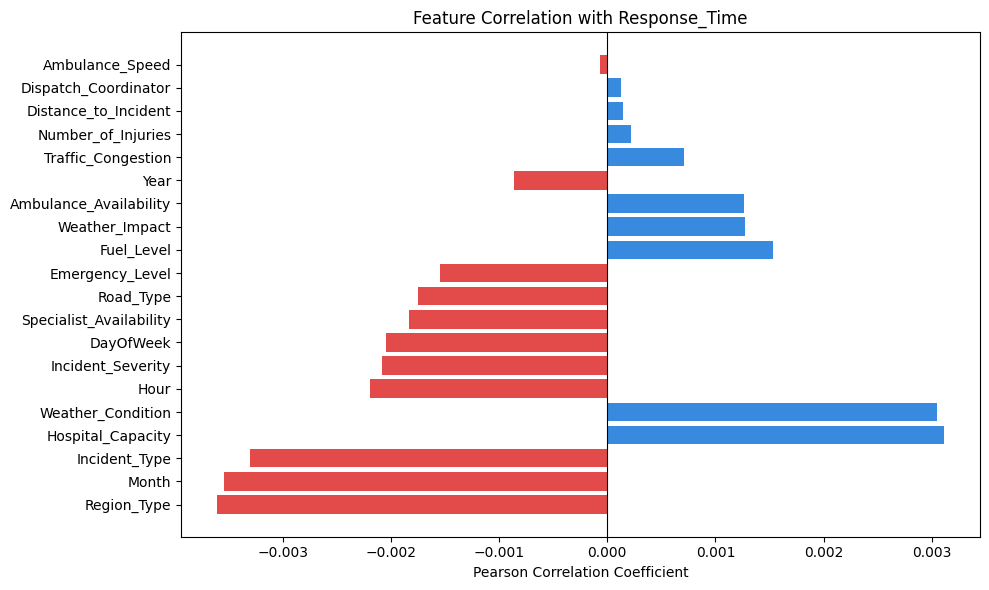

Chart saved as phase0_correlation_bar.png


In [18]:
# Visual bar chart of correlations
plt.figure(figsize=(10, 6))
colors = ['#378ADD' if v >= 0 else '#E24B4A' for v in corr_with_target.values]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation Coefficient')
plt.title('Feature Correlation with Response_Time')
plt.tight_layout()
plt.savefig('phase0_correlation_bar.png', dpi=150)
plt.show()
print('Chart saved as phase0_correlation_bar.png')

---
## 11. Save Cleaned Datasets

In [19]:
# Save the original (with parsed Timestamp and time features) for descriptive analytics
df.to_csv('df_clean.csv', index=False)

# Save the encoded version for predictive and prescriptive analytics
df_encoded.to_csv('df_encoded.csv', index=False)

print('Saved: df_clean.csv   (original + time features, for Activity 1)')
print('Saved: df_encoded.csv (fully numeric, for Activities 2 & 3)')
print()
print(f'df_clean   shape: {df.shape}')
print(f'df_encoded shape: {df_encoded.shape}')

Saved: df_clean.csv   (original + time features, for Activity 1)
Saved: df_encoded.csv (fully numeric, for Activities 2 & 3)

df_clean   shape: (155779, 22)
df_encoded shape: (155779, 21)


---
## 12. Phase 0 Summary

| Item | Value |
|------|-------|
| Total records | 368,065 |
| Total features | 18 (+ 4 extracted time features) |
| Numeric features | 6 |
| Categorical features | 11 |
| Target variable | Response_Time (float64) |
| Time range | 2018 – 2024 (10-min intervals) |
| Missing values | See Cell 4 output |
| Duplicates | See Cell 8 output |

**Next step:** Run Activity 1 — Descriptive Analytics using `df_clean.csv`